# SQLite and Visuals

Import libraries

In [36]:
import pandas as pd 
import matplotlib.pyplot as plt
import sqlite3
import plotly.express as px
from mpl_toolkits.basemap import Basemap
import matplotlib.pyplot as plt
import nbformat as nbf
import plotly.io as pio


Import data

In [37]:
hpi_df = pd.read_csv('data/hpi_clean.csv')
med_inc_df = pd.read_csv('data/median_income_clean_w_change.csv')

In [38]:
conn = sqlite3.connect("hpi_v_medinc.db")
cursor = conn.cursor()

In [39]:
cursor.execute("""
CREATE TABLE IF NOT EXISTS hpi (
    hpi_type TEXT NOT NULL,
    hpi_flavor TEXT NOT NULL,
    frequency TEXT PRIMARY KEY,
    level TEXT NOT NULL,
    place_name REAL NOT NULL,
    yr TEXT NOT NULL,
    index_nsa TEST NOT NULL          
);        
""")

cursor.execute("""
CREATE TABLE IF NOT EXISTS medinc (
    place_name TEXT NOT NULL,
    yr TEXT NOT NULL,
    median_income TEXT NOT NULL,
    change TEXT NOT NULL
);
""")

hpi_df.to_sql('hpi', conn, if_exists='replace', index=False)
med_inc_df.to_sql('medinc', conn, if_exists='replace', index=False)

print(pd.read_sql_query("SELECT * FROM hpi LIMIT 5", conn))
print(pd.read_sql_query("SELECT * FROM medinc LIMIT 5", conn))

      hpi_type     hpi_flavor  frequency  level place_name place_id    yr  \
0  traditional  purchase-only  quarterly  State     Alaska       AK  1991   
1  traditional  purchase-only  quarterly  State     Alaska       AK  1992   
2  traditional  purchase-only  quarterly  State     Alaska       AK  1993   
3  traditional  purchase-only  quarterly  State     Alaska       AK  1994   
4  traditional  purchase-only  quarterly  State     Alaska       AK  1995   

   period  index_nsa  index_sa  
0       1     100.00    100.00  
1       1     103.06    103.01  
2       1     105.16    105.02  
3       1     111.51    111.26  
4       1     114.80    114.52  
  place_name    yr median_income  change standard_error
0    Alabama  1991        24,350  100.00          1,068
1    Alabama  1992        25,810  106.00          1,058
2    Alabama  1993        25,080  103.00          1,088
3    Alabama  1994        27,200  111.70          1,559
4    Alabama  1995        25,990  106.74          1,266


Query to show the largest gap between HPI and Median Income. I am also creating a new datafram to use in a visualization

In [40]:
def query(query: str):
    return pd.read_sql(query, conn)

In [41]:
main_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap DESC

""")

Query to show the ten states with the lowest gap between HPI and Median Income.


In [42]:
lowest_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap ASC
Limit 10  
""")

lowest_gap_df   



,place_name,yr,hpi,income_index,gap
0,Mississippi,2024,296.37,287.37,9.00
1,West Virginia,2024,295.26,272.79,22.47
2,Illinois,2024,291.64,264.15,27.49
3,Connecticut,2024,274.83,235.44,39.39
4,Ohio,2024,319.22,270.29,48.93
5,Iowa,2024,351.32,299.40,51.92
6,Indiana,2024,340.39,283.17,57.22
7,Maryland,2024,354.20,296.89,57.31
8,Delaware,2024,331.62,263.46,68.16
9,North Dakota,2024,409.03,340.21,68.82


Query to show the 10 states with the largest gap between HPI and Median Income

In [43]:
largest_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap DESC
Limit 10
""")

Query to show the most affordable states to live in in the years 1991 - 2024 showing a long term affordability not just current affordability. 

In [44]:
affordability_over_time_df = query("""
SELECT
    h.place_name,
    AVG(h.index_nsa / m.change) AS affordability_ratio
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
GROUP BY h.place_name
ORDER BY affordability_ratio ASC
LIMIT 10;
""")

Function to determine the gap between housing vs income gap for the years 1991 - 2024. This is for comparing two states.

In [45]:
def compare_states_with_gap(state1, state2):
    query_str = f"""
    SELECT
        h.place_name,
        h.yr,
        h.index_nsa AS hpi,
        m.change AS income_index,
        (h.index_nsa - m.change) AS gap
    FROM hpi h
    JOIN medinc m
        ON h.place_name = m.place_name
        AND h.yr = m.yr
    WHERE h.place_name IN ('{state1}', '{state2}')
    ORDER BY h.place_name, h.yr
    """
    
    return query(query_str)

In [46]:
def plot_compare_states_gap(state, state2):
    df = compare_states_with_gap(state, state2)


    plt.figure(figsize=(12, 6))


    for state in df['place_name'].unique():
        subset = df[df['place_name'] == state]
        plt.plot(
            subset['yr'],
            subset['gap'],
            linewidth=2.5,
            marker='o',
            markersize=5,
            label=state
    )


    plt.title('Housing vs Income Gap Over Time', fontsize=16, weight='bold')
    plt.xlabel('Year', fontsize=12)
    plt.ylabel('Gap (HPI - Income Index)', fontsize=12)


    plt.grid(alpha=0.3)


    plt.legend(title='State', fontsize=10)


    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)


    plt.tight_layout()

    plt.show()

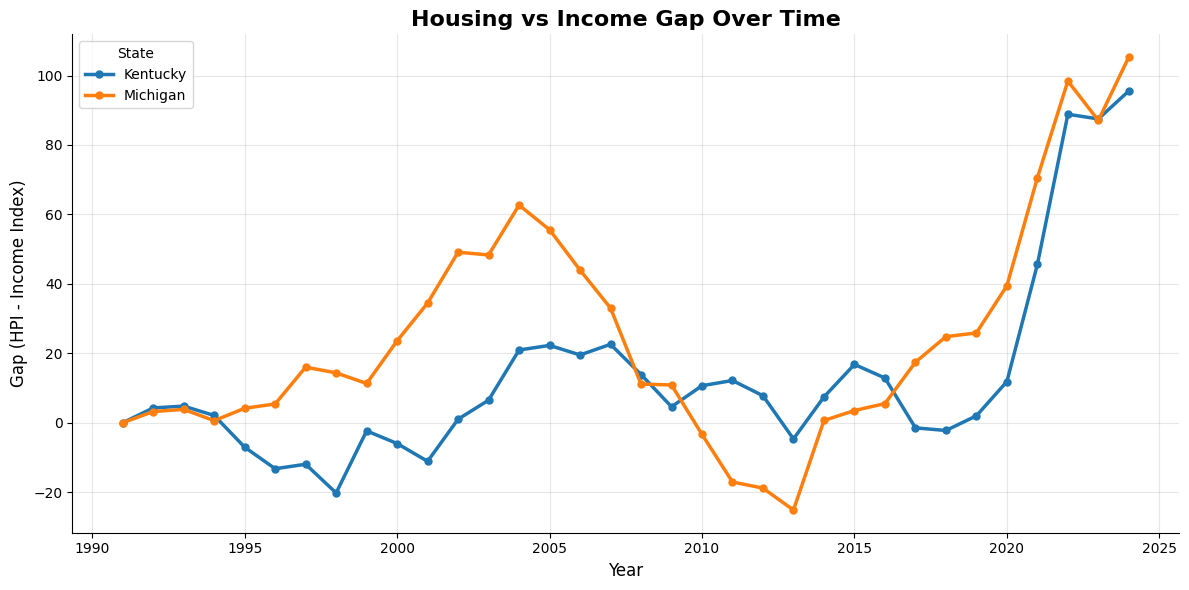

In [47]:
plot_compare_states_gap('Kentucky', 'Michigan')

In [48]:
def plot_state_hpi_vs_income(state):
    df = compare_states_with_gap(state, state) 

    subset = df[df['place_name'] == state]

    plt.figure(figsize=(12, 6))

    
    plt.plot(
        subset['yr'],
        subset['hpi'],
        linewidth=2.5,
        marker='o',
        label='HPI (Housing)'
    )

    
    plt.plot(
        subset['yr'],
        subset['income_index'],
        linewidth=2.5,
        linestyle='--',
        marker='o',
        label='Income'
    )

    
    plt.axhline(100, linestyle='--', linewidth=1)

    
    plt.title(f'{state}: Housing vs Income Growth', fontsize=16, weight='bold')
    plt.xlabel('Year')
    plt.ylabel('Index (Base = 100)')

    
    plt.grid(alpha=0.3)
    plt.legend()
    plt.gca().spines['top'].set_visible(False)
    plt.gca().spines['right'].set_visible(False)

    plt.tight_layout()
    plt.show()

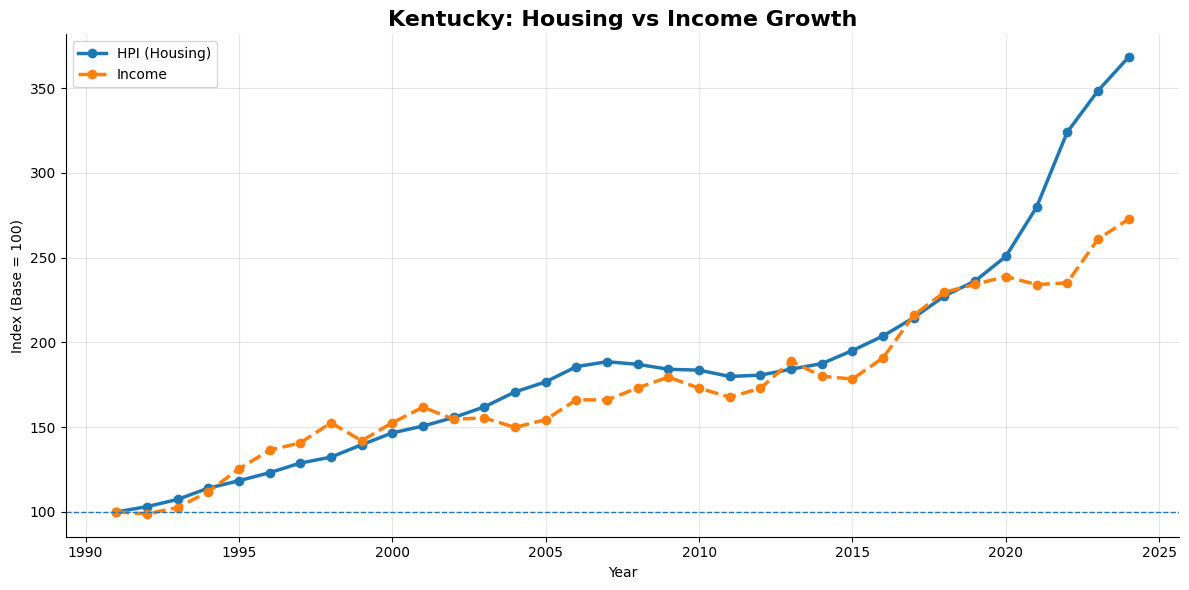

In [49]:
plot_state_hpi_vs_income('Kentucky')

In [56]:
usa_med_inc_hpi_gap_df = query("""
SELECT
    h.place_name,
    h.yr,
    h.index_nsa AS hpi,
    m.change AS income_index,
    (h.index_nsa - m.change) AS gap
FROM hpi h
JOIN medinc m
    ON h.place_name = m.place_name
    AND h.yr = m.yr
WHERE h.yr = 2024
ORDER BY gap DESC
""")

In [57]:
state_map = {
    'Alabama': 'AL','Alaska': 'AK','Arizona': 'AZ','Arkansas': 'AR',
    'California': 'CA','Colorado': 'CO','Connecticut': 'CT','Delaware': 'DE',
    'Florida': 'FL','Georgia': 'GA','Hawaii': 'HI','Idaho': 'ID',
    'Illinois': 'IL','Indiana': 'IN','Iowa': 'IA','Kansas': 'KS',
    'Kentucky': 'KY','Louisiana': 'LA','Maine': 'ME','Maryland': 'MD',
    'Massachusetts': 'MA','Michigan': 'MI','Minnesota': 'MN','Mississippi': 'MS',
    'Missouri': 'MO','Montana': 'MT','Nebraska': 'NE','Nevada': 'NV',
    'New Hampshire': 'NH','New Jersey': 'NJ','New Mexico': 'NM','New York': 'NY',
    'North Carolina': 'NC','North Dakota': 'ND','Ohio': 'OH','Oklahoma': 'OK',
    'Oregon': 'OR','Pennsylvania': 'PA','Rhode Island': 'RI','South Carolina': 'SC',
    'South Dakota': 'SD','Tennessee': 'TN','Texas': 'TX','Utah': 'UT',
    'Vermont': 'VT','Virginia': 'VA','Washington': 'WA','West Virginia': 'WV',
    'Wisconsin': 'WI','Wyoming': 'WY'
}

In [58]:
usa_med_inc_hpi_gap_df['place_id'] = usa_med_inc_hpi_gap_df['place_name'].map(state_map)

In [59]:
usa_med_inc_hpi_gap_df[['place_name','place_id']].head()

,place_name,place_id
0,Montana,MT
1,Colorado,CO
2,Utah,UT
3,Oregon,OR
4,Idaho,ID


In [68]:
fig = px.choropleth(
    usa_med_inc_hpi_gap_df,
    locations='place_id',
    locationmode='USA-states',
    scope='usa',
    color='gap',
    color_continuous_scale='Jet',   
    range_color=[0, 400],              
    hover_data={'gap': ':.2f'},
    title='Housing vs Income Gap by State (2024)'

)
fig.update_layout(height=500, width=800)
fig.show()